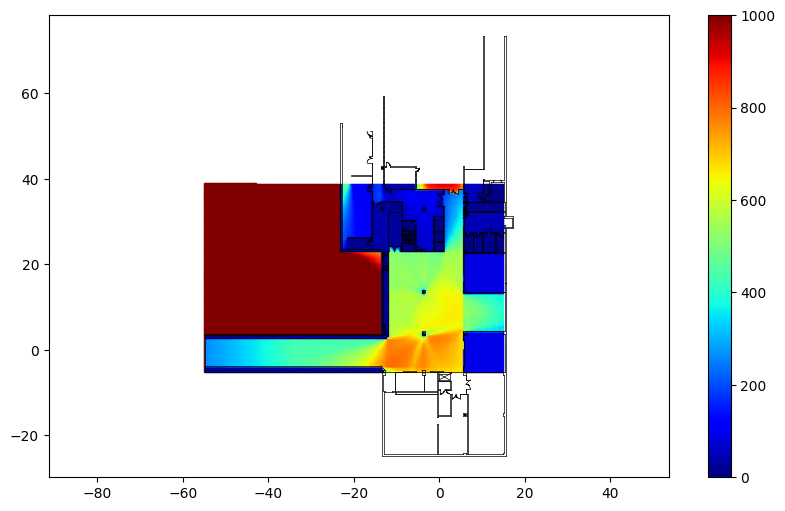

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_csv = f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/vis_2d_360deg.csv'
results_df = pd.read_csv(results_csv)

lines_json = '../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/anlieferung_plan.json'
lines_df = pd.read_json(lines_json)
lines_2d = []
for row in lines_df.iterrows():
    start = row[1]['start'][:2]
    end = row[1]['end'][:2]
    lines_2d.append([start,end])
lines_2d = np.array(lines_2d)

plt.figure(figsize=(10,6))
for row in lines_2d:
    start = row[0,:]
    end = row[1,:]
    line = np.array([start,end])
    plt.plot(line[:,0],line[:,1],color=(0,0,0),linewidth=0.5)
plt.axis('equal')
subset = results_df[['posX', 'posY', 'area_calc']].to_numpy() #calculated area
subset[:,2] = np.clip(subset[:,2],0,1e3)
plt.scatter(subset[:,0],subset[:,1],s=0.6,marker='s',c=subset[:,2],cmap='jet',alpha=1,vmin=0, vmax=1000)
plt.colorbar()

In [8]:
from pathlib import Path
import pandas as pd
import meshio
import open3d as o3d

mesh = Path('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/delivery_area/scan_raw/scan1.ply')
with mesh.open("rb") as f:
    raw = f.read(4096)

text = raw.decode("ascii", errors="ignore")
end = text.find("end_header")
if end == -1:
    print("No 'end_header' found in the first 4096 bytes.")
    print(text)
else:
    header = text[:end + len("end_header")]
    print(header)

m = o3d.io.read_triangle_mesh(mesh)

print(m)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
ply
format binary_little_endian 1.0
comment PCL generated
element vertex 27190910
property float x
property float y
property float z
property uchar red
property uchar green
property uchar blue
element camera 1
property float view_px
property float view_py
property float view_pz
property float x_axisx
property float x_axisy
property float x_axisz
property float y_axisx
property float y_axisy
property float y_axisz
property float z_axisx
property float z_axisy
property float z_axisz
property float focal
property float scalex
property float scaley
property float centerx
property float centery
property int viewportx
property int viewporty
property float k1
property float k2
end_header
[Open3D WARNING] geometry::TriangleMesh appears to be a geometry::PointCloud (only contains vertices, but no triangles).
TriangleMesh with 27

In [5]:
from pathlib import Path
import numpy as np

PLY_PATH = Path('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/delivery_area/scan_raw/scan1.ply')

def read_ply_header_and_offset(p: Path):
    """Return (header_text, payload_offset_bytes)."""
    with p.open("rb") as f:
        header_bytes = bytearray()
        while True:
            line = f.readline()
            if not line:
                raise ValueError("EOF before end_header.")
            header_bytes += line
            if line in (b"end_header\n", b"end_header\r\n"):
                break
        return header_bytes.decode("ascii"), f.tell()

def parse_counts_and_layout(header: str):
    """Extract vertex count and confirm camera element exists."""
    n_vertex = None
    n_camera = 0
    for line in header.splitlines():
        if line.startswith("element vertex "):
            n_vertex = int(line.split()[-1])
        elif line.startswith("element camera "):
            n_camera = int(line.split()[-1])
    if n_vertex is None:
        raise ValueError("No 'element vertex' found in header.")
    return n_vertex, n_camera

# Camera layout exactly matching your header (little-endian)
camera_dtype = np.dtype(
    [
        ("view_px", "<f4"), ("view_py", "<f4"), ("view_pz", "<f4"),
        ("x_axisx", "<f4"), ("x_axisy", "<f4"), ("x_axisz", "<f4"),
        ("y_axisx", "<f4"), ("y_axisy", "<f4"), ("y_axisz", "<f4"),
        ("z_axisx", "<f4"), ("z_axisy", "<f4"), ("z_axisz", "<f4"),
        ("focal", "<f4"),
        ("scalex", "<f4"), ("scaley", "<f4"),
        ("centerx", "<f4"), ("centery", "<f4"),
        ("viewportx", "<i4"), ("viewporty", "<i4"),
        ("k1", "<f4"), ("k2", "<f4"),
    ],
    align=False,
)

def extract_camera(p: Path):
    header, payload_offset = read_ply_header_and_offset(p)
    n_vertex, n_camera = parse_counts_and_layout(header)

    if n_camera != 1:
        raise ValueError(f"Expected element camera 1, found element camera {n_camera}.")

    # Your vertex record: 3*float32 + 3*uint8 = 12 + 3 = 15 bytes
    bytes_per_vertex = 15
    camera_offset = payload_offset + n_vertex * bytes_per_vertex

    with p.open("rb") as f:
        f.seek(camera_offset)
        cam = np.fromfile(f, dtype=camera_dtype, count=1)
        if cam.size != 1:
            raise ValueError("Could not read camera record (file may be truncated).")
        return cam[0]

cam = extract_camera(PLY_PATH)

# Print values nicely
for name in cam.dtype.names:
    print(f"{name:>10}: {cam[name]}")

# Helpful derived structures:
view_pos = np.array([cam["view_px"], cam["view_py"], cam["view_pz"]], dtype=np.float32)

R = np.array(
    [
        [cam["x_axisx"], cam["y_axisx"], cam["z_axisx"]],
        [cam["x_axisy"], cam["y_axisy"], cam["z_axisy"]],
        [cam["x_axisz"], cam["y_axisz"], cam["z_axisz"]],
    ],
    dtype=np.float32,
)

K = np.array(
    [
        [cam["focal"] * cam["scalex"], 0.0, cam["centerx"]],
        [0.0, cam["focal"] * cam["scaley"], cam["centery"]],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float32,
)

print("\nCamera position:", view_pos)
print("\nRotation matrix (from axes):\n", R)
print("\nApprox intrinsics K:\n", K)
print("\nDistortion k1,k2:", float(cam["k1"]), float(cam["k2"]))
print("Viewport:", int(cam["viewportx"]), "x", int(cam["viewporty"]))


   view_px: 0.0
   view_py: 0.0
   view_pz: 0.0
   x_axisx: 1.0
   x_axisy: 0.0
   x_axisz: 0.0
   y_axisx: 0.0
   y_axisy: 1.0
   y_axisz: 0.0
   z_axisx: 0.0
   z_axisy: 0.0
   z_axisz: 1.0
     focal: 0.0
    scalex: 0.0
    scaley: 0.0
   centerx: 0.0
   centery: 0.0
 viewportx: 27190910
 viewporty: 1
        k1: 0.0
        k2: 0.0

Camera position: [0. 0. 0.]

Rotation matrix (from axes):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Approx intrinsics K:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 1.]]

Distortion k1,k2: 0.0 0.0
Viewport: 27190910 x 1


In [ ]:
from pathlib import Path

src = Path('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/delivery_area/scan_raw/scan2.ply')
dst = Path('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/delivery_area/scan_raw/scan2_no_camera.ply')

# 1) Read header (binary-safe), find end_header
data = src.read_bytes()  # If file is huge, use the streaming variant below.
marker1 = b"end_header\n"
marker2 = b"end_header\r\n"

if marker1 in data:
    h_end = data.index(marker1) + len(marker1)
elif marker2 in data:
    h_end = data.index(marker2) + len(marker2)
else:
    raise ValueError("Could not find end_header line.")

header = data[:h_end].decode("ascii", errors="strict")

# 2) Parse vertex count from the header (simple approach)
lines = header.splitlines()
n_verts = None
for line in lines:
    if line.startswith("element vertex "):
        n_verts = int(line.split()[-1])
        break
if n_verts is None:
    raise ValueError("No 'element vertex' line found.")

bytes_per_vertex = 15
vertex_bytes = n_verts * bytes_per_vertex

# 3) Build a new header with only vertex properties (no camera element)
new_header_lines = []
in_camera_block = False
for line in lines:
    if line.startswith("element camera "):
        in_camera_block = True
        continue
    if in_camera_block:
        # Skip camera properties until end_header
        if line.strip() == "end_header":
            in_camera_block = False
            new_header_lines.append("end_header")
        continue
    new_header_lines.append(line)

new_header = ("\n".join(new_header_lines) + "\n").encode("ascii")

# 4) Copy vertex payload only (ignore camera payload)
payload_start = h_end
payload_end = payload_start + vertex_bytes

if payload_end > len(data):
    raise ValueError(
        f"File too small for declared vertex count. "
        f"Need at least {payload_end} bytes, have {len(data)}."
    )

with dst.open("wb") as f:
    f.write(new_header)
    f.write(data[payload_start:payload_end])

print(f"Wrote {dst} with {n_verts} vertices, stripped camera element.")


Wrote ../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/delivery_area/scan_raw/scan2_no_camera.ply with 27273850 vertices, stripped camera element.


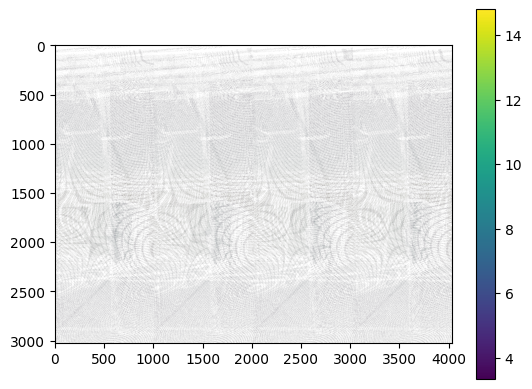

In [1]:
import numpy as np
import matplotlib.pyplot as plt

depth_path = ('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/delivery_area/ground_truth_depth/dslr_images/DSC_0681.JPG')

depth = np.fromfile(depth_path,dtype="<f4")
depth = depth.reshape(3024,4032,2)
plt.imshow(depth[:,:,0])
plt.colorbar()

In [17]:
camera_intrinsics = {'W':6208,'H':4135,'fx':3408.59,'fy':3408.87,'cx':3117.24,'cy':2064.07}
fov_x = 2*np.arctan(camera_intrinsics['W']/(2*camera_intrinsics['fx']))
fov_x_deg = np.rad2deg(fov_x)

(-10.0, 10.0)

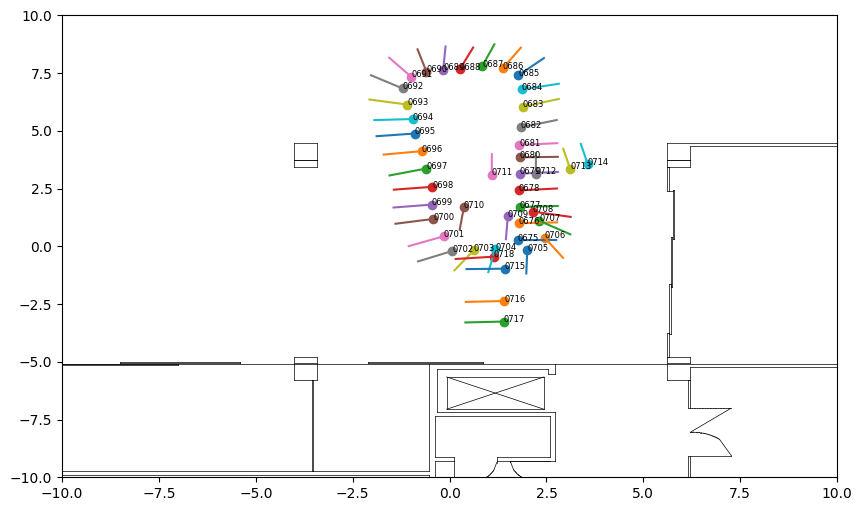

In [9]:
from scipy.spatial.transform import Rotation as R
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from preprocessing_src.area_methods import compute_area_directional

images_path = '../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/delivery_area/dslr_calibration_undistorted/images_parsed.csv'
images_df = pd.read_csv(images_path)

lines_json = '../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/anlieferung_plan.json'
lines_df = pd.read_json(lines_json)
lines_2d = []
for row in lines_df.iterrows():
    start = row[1]['start'][:2]
    end = row[1]['end'][:2]
    lines_2d.append([start,end])
lines_2d = np.array(lines_2d)

plt.figure(figsize=(10,6))
for row in lines_2d:
    start = row[0,:]
    end = row[1,:]
    line = np.array([start,end])
    plt.plot(line[:,0],line[:,1],color=(0,0,0),linewidth=0.5)
#plt.axis('equal')

for _, point in images_df.iterrows():
    qx,qy,qz,qw = point.loc[['qx','qy','qz','qw']].to_numpy()
    R_wc = R.from_quat([qx, qy, qz, qw]).as_matrix()

    tx,ty,tz = point.loc[['tx','ty','tz']].to_numpy()
    #translation from quaternion, translation matrices to camera coords
    t_wc = np.array([tx, ty, tz])
    # camera center in world coordinates
    C = -R_wc.T @ t_wc
    d_cam = np.array([0.0, 0.0, 1.0])
    # camera view direction (center)
    d_world = R_wc.T @ d_cam
    d_world = d_world/(np.linalg.norm(d_world))
    #print(C,d_world)
    plt.scatter(C[0],C[1],label=point['image_name'])
    name = point["image_name"].split('DSC_')[1].split('.JPG')[0]
    plt.text(C[0], C[1] - 0.02, name, fontsize=6)
    dir_view = C+d_world
    line = np.array([C,dir_view])
    plt.plot(line[:,0],line[:,1])
    #area,dists = compute_area_directional(lines_2d,M,N,[C[0],C[1]],D,d_world[:2],fov_x)
N = 360
D = 40
M = 'segments_angle'

#plt.legend()
plt.xlim(-10,10)
plt.ylim(-10,10)